In [3]:
from IPython import get_ipython
from IPython.display import display

In [4]:
!pip install torch
!pip install torch-geometric
!pip install tensorflow
!pip install networkx
!pip install matplotlib
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00a 0:00:01


In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
import torch.nn.functional as F # Import F for using null_loss
from sklearn.neighbors import kneighbors_graph


nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab')

# Step 1: Load Data
def load_data(fake_path, true_path):
    fake_df = pd.read_csv(fake_path)
    true_df = pd.read_csv(true_path)
    fake_df['label'] = 0
    true_df['label'] = 1
    df = pd.concat([fake_df, true_df], ignore_index=True)
    df = df[['text', 'label']]
    return df.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 2: Text Preprocessing
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'@\w+|#\w+|http\S+|www\S+|[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Step 3: Prepare Tokenized Data
def prepare_data(df, max_features=500):
    df['text'] = df['text'].apply(preprocess_text)
    texts = df['text'].values
    labels = df['label'].values

    tokenizer = TfidfVectorizer(max_features=max_features)
    X = tokenizer.fit_transform(texts).toarray()
    y = df['label'].values
    max_len = 100

    return torch.tensor(X, dtype=torch.float), torch.tensor(y, dtype=torch.long), tokenizer

# Step 4: Convert Data to Graph Representation
def create_graph_data(X, y, k=10): # Added k parameter for k-NN
    num_nodes = X.shape[0]
    # Create k-NN graph using cosine similarity
    adj_matrix = kneighbors_graph(X, n_neighbors=k, metric='cosine', mode='connectivity')
    edge_index = torch.tensor(np.argwhere(adj_matrix.toarray() != 0).T, dtype=torch.long) # Changed to kNN Graph

    # Train test split
    X_train, X_test = train_test_split(np.arange(num_nodes), test_size=0.2, stratify=y)
    train_mask = torch.tensor(X_train, dtype=torch.long)
    test_mask = torch.tensor(X_test, dtype=torch.long)

    #edge_index = edge_index.t().contiguous() # Removed this line as it's not needed anymore
    data = Data(x=X, edge_index=edge_index, y=y)
    data.train_mask = train_mask # Corrected to train_mask
    data.test_mask = test_mask
    return data

# Step 5: Define GNN Models
def get_gcn(input_dim, hidden_dim, output_dim):
  class GCNModel(torch.nn.Module):
      def __init__(self):
          super(GCNModel, self).__init__()
          self.conv1 = GCNConv(input_dim, hidden_dim)
          self.conv2 = GCNConv(hidden_dim, output_dim)
          self.relu = nn.ReLU()

      def forward(self, data):
          x, edge_index = data.x, data.edge_index
          x = self.conv1(x, edge_index)
          x = self.relu(x)
          x = self.conv2(x, edge_index)
          return F.log_softmax(x, dim=1)
  return GCNModel()

def get_gat(input_dim, hidden_dim, output_dim):
  class GATModel(torch.nn.Module):
      def __init__(self):
          super(GATModel, self).__init__()
          self.conv1 = GATConv(input_dim, hidden_dim)
          self.conv2 = GATConv(hidden_dim, output_dim)
          self.relu = nn.ReLU()

      def forward(self, data):
          x, edge_index = data.x, data.edge_index
          x = self.conv1(x, edge_index)
          x = self.relu(x)
          x = self.conv2(x, edge_index)
          return F.log_softmax(x, dim=1)
  return GATModel()

def get_graphsage(input_dim, hidden_dim, output_dim):
  class GraphSAGEModel(torch.nn.Module):
      def __init__(self):
          super(GraphSAGEModel, self).__init__()
          self.conv1 = SAGEConv(input_dim, hidden_dim)
          self.conv2 = SAGEConv(hidden_dim, output_dim)
          self.relu = nn.ReLU()

      def forward(self, data):
          x, edge_index = data.x, data.edge_index
          x = self.conv1(x, edge_index)
          x = self.relu(x)
          x = self.conv2(x, edge_index)
          return F.log_softmax(x, dim=1)
  return GraphSAGEModel()

# Step 6: Train & Evaluate Model
def train_and_evaluate(model, data, epochs=20, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        preds = out.argmax(dim=1)
        train_acc = (preds[data.train_mask] == data.y[data.train_mask]).sum().item() / len(data.train_mask)

        model.eval()
        with torch.no_grad():
            val_loss = F.nll_loss(out[data.test_mask], data.y[data.test_mask]).item()
            val_acc = (preds[data.test_mask] == data.y[data.test_mask]).sum().item() / len(data.test_mask)

        # Append metrics after each epoch (this is the key change)
        history['train_acc'].append(train_acc)
        history['train_loss'].append(loss.item())
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Acc: {train_acc:.4f}, Train Loss: {loss.item():.4f}, Val Acc: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

    return model, history


def evaluate_model(model, data, model_name):
    model.eval()
    with torch.no_grad():
      out = model(data)
      preds = out.argmax(dim=1)
      y_true = data.y[data.test_mask].cpu().numpy()
      y_pred = preds[data.test_mask].cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    # Calculate ROC and AUC
    probs = out [:, 1].cpu().numpy()
    fpr, tpr, _ = roc_curve(y_true, probs[data.test_mask]) # Extract probability for positive class
    roc_auc = auc(fpr, tpr)

    print(f"{model_name} - Accuracy: {acc:.2f}, Precision: {prec:.2f}, Recall: {rec:.2f}, F1 Score: {f1:.2f}, AUC: {roc_auc:.2f}")
    print("Confusion Matrix:")
    print(cm)
    return {
        "model": model,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "conf_matrix": cm,
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc
    }

# Plot Training and Validation curve
def plot_history(history, model_name):
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{model_name} - Training and Validation Accuracy')
    plt.show()
    plt.savefig(f'{model_name}_training and validation accuracy.png')

    plt.figure(figsize=(10, 6))
    plt.plot(history['train_loss'], label='Train Loss') # Changed from history.history['train_loss'] to history['train_loss']
    plt.plot(history['val_loss'], label='Validation Loss') # Changed from history.history['val_loss'] to history['val_loss']
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{model_name} - Training and Validation Loss')
    plt.show()
    plt.savefig(f'{model_name}_training and validation loss.png')

# Step 6: Plot Confusion Matrix and ROC Curve
def plot_comparison(results):
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

    model_names = list(results.keys())
    scores = {metric: [results[model_name][metric] for model_name in model_names] for metric in metrics}

    x = np.arange(len(model_names))  # the label locations
    width = 0.2  # the width of the bars

    fig, ax = plt.subplots(figsize=(8, 6))

    # Add some text for labels, title and custom x-axis tick labels, etc.
    for i, metric in enumerate(metrics):
        ax.bar(x + i * width, scores[metric], width, label=metric_names[i])

    ax.set_xlabel('Models')
    ax.set_ylabel('Scores')
    ax.set_title('Performance Metrics')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(model_names)
    ax.legend()

    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig('Model_Performance_Comparison.png')
    plt.show()

def plot_confusion_matrix(conf_matrix, model_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f'{model_name}_confusion_matrix.png')
    plt.show()

def plot_roc_curves(results):
    plt.figure(figsize=(8, 6))
    for model_name, result in results.items():
        plt.plot(result['fpr'], result['tpr'], lw=2, label=f'{model_name} (AUC = {result["roc_auc"]:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend(loc="lower right")
    plt.savefig('combined_roc_curve.png')
    plt.show()




[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Using device: cuda

===== Training GCN =====
Epoch 1/20, Train Acc: 0.4994, Train Loss: 0.6981, Val Acc: 0.4965, Val Loss: 0.6980
Epoch 2/20, Train Acc: 0.8296, Train Loss: 0.6266, Val Acc: 0.8315, Val Loss: 0.6265
Epoch 3/20, Train Acc: 0.8666, Train Loss: 0.5534, Val Acc: 0.8659, Val Loss: 0.5536
Epoch 4/20, Train Acc: 0.8890, Train Loss: 0.4753, Val Acc: 0.8890, Val Loss: 0.4759
Epoch 5/20, Train Acc: 0.8945, Train Loss: 0.4079, Val Acc: 0.8924, Val Loss: 0.4088
Epoch 6/20, Train Acc: 0.8938, Train Loss: 0.3574, Val Acc: 0.8927, Val Loss: 0.3586
Epoch 7/20, Train Acc: 0.8970, Train Loss: 0.3202, Val Acc: 0.8952, Val Loss: 0.3218
Epoch 8/20, Train Acc: 0.9021, Train Loss: 0.2941, Val Acc: 0.8982, Val Loss: 0.2963
Epoch 9/20, Train Acc: 0.9055, Train Loss: 0.2763, Val Acc: 0.9009, Val Loss: 0.2795
Epoch 10/20, Train Acc: 0.9079, Train Loss: 0.2631, Val Acc: 0.9043, Val Loss: 0.2674
Epoch 11/20, Train Acc: 0.9095, Train Loss: 0.2535, Val Acc: 0.9067, Val Loss: 0.2591
Epoch 12/20, Train

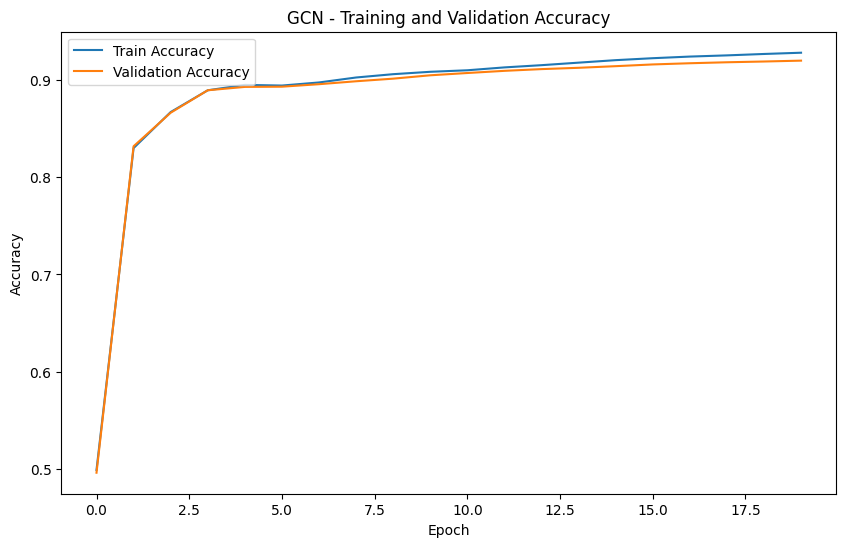

<Figure size 640x480 with 0 Axes>

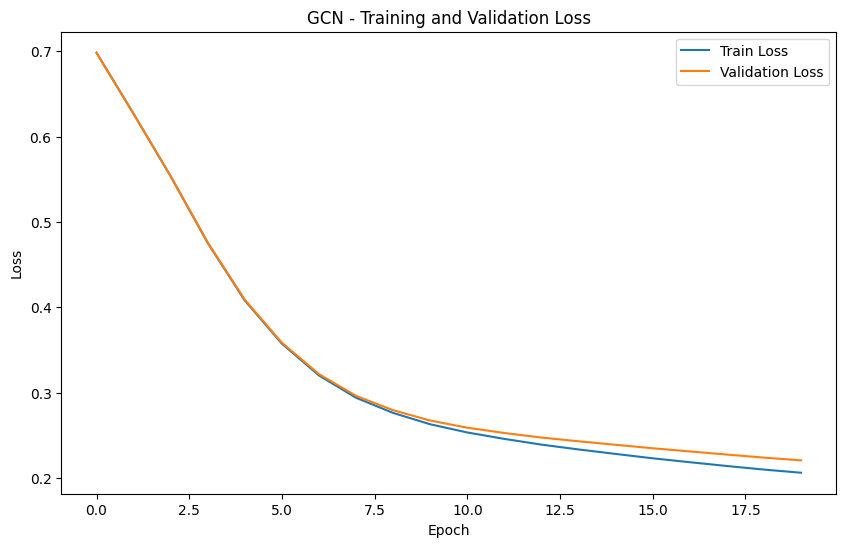


===== Training GAT =====
Epoch 1/20, Train Acc: 0.5299, Train Loss: 0.6924, Val Acc: 0.5206, Val Loss: 0.6928
Epoch 2/20, Train Acc: 0.8470, Train Loss: 0.6347, Val Acc: 0.8451, Val Loss: 0.6351
Epoch 3/20, Train Acc: 0.8728, Train Loss: 0.5728, Val Acc: 0.8688, Val Loss: 0.5734
Epoch 4/20, Train Acc: 0.8850, Train Loss: 0.5044, Val Acc: 0.8806, Val Loss: 0.5053
Epoch 5/20, Train Acc: 0.8915, Train Loss: 0.4388, Val Acc: 0.8878, Val Loss: 0.4402
Epoch 6/20, Train Acc: 0.8933, Train Loss: 0.3830, Val Acc: 0.8909, Val Loss: 0.3849
Epoch 7/20, Train Acc: 0.8957, Train Loss: 0.3382, Val Acc: 0.8925, Val Loss: 0.3408
Epoch 8/20, Train Acc: 0.8991, Train Loss: 0.3034, Val Acc: 0.8944, Val Loss: 0.3069
Epoch 9/20, Train Acc: 0.9028, Train Loss: 0.2772, Val Acc: 0.8986, Val Loss: 0.2818
Epoch 10/20, Train Acc: 0.9061, Train Loss: 0.2580, Val Acc: 0.9033, Val Loss: 0.2640
Epoch 11/20, Train Acc: 0.9091, Train Loss: 0.2438, Val Acc: 0.9062, Val Loss: 0.2512
Epoch 12/20, Train Acc: 0.9123, Train

<Figure size 640x480 with 0 Axes>

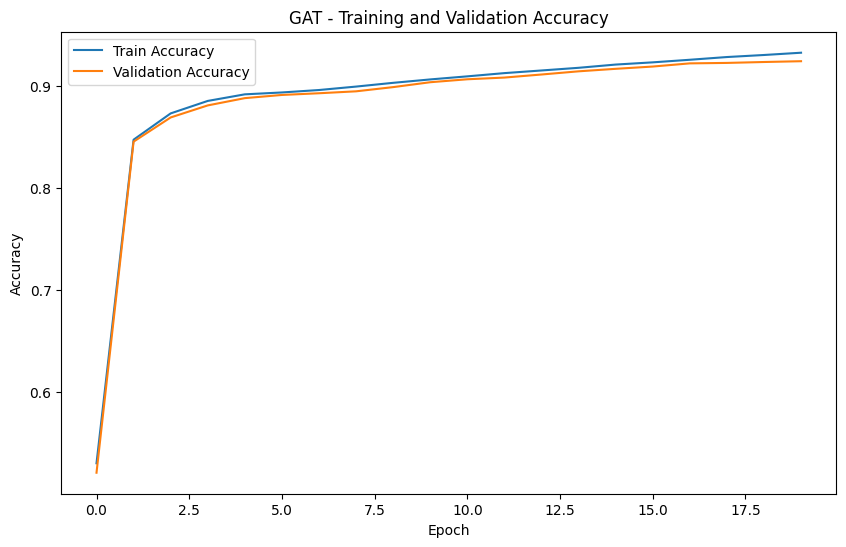

<Figure size 640x480 with 0 Axes>

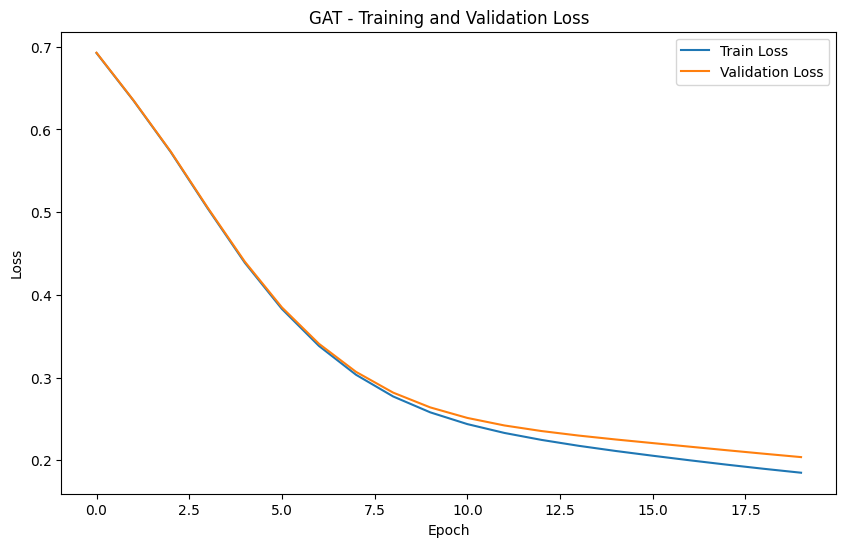


===== Training GraphSAGE =====
Epoch 1/20, Train Acc: 0.5230, Train Loss: 0.6929, Val Acc: 0.5229, Val Loss: 0.6929
Epoch 2/20, Train Acc: 0.8543, Train Loss: 0.6380, Val Acc: 0.8461, Val Loss: 0.6382
Epoch 3/20, Train Acc: 0.8750, Train Loss: 0.5470, Val Acc: 0.8720, Val Loss: 0.5476
Epoch 4/20, Train Acc: 0.8908, Train Loss: 0.4515, Val Acc: 0.8880, Val Loss: 0.4529
Epoch 5/20, Train Acc: 0.9029, Train Loss: 0.3662, Val Acc: 0.8998, Val Loss: 0.3686
Epoch 6/20, Train Acc: 0.9069, Train Loss: 0.3028, Val Acc: 0.9027, Val Loss: 0.3065
Epoch 7/20, Train Acc: 0.9118, Train Loss: 0.2616, Val Acc: 0.9062, Val Loss: 0.2671
Epoch 8/20, Train Acc: 0.9170, Train Loss: 0.2358, Val Acc: 0.9116, Val Loss: 0.2437
Epoch 9/20, Train Acc: 0.9218, Train Loss: 0.2207, Val Acc: 0.9164, Val Loss: 0.2311
Epoch 10/20, Train Acc: 0.9276, Train Loss: 0.2089, Val Acc: 0.9212, Val Loss: 0.2215
Epoch 11/20, Train Acc: 0.9317, Train Loss: 0.1993, Val Acc: 0.9238, Val Loss: 0.2139
Epoch 12/20, Train Acc: 0.9352,

<Figure size 640x480 with 0 Axes>

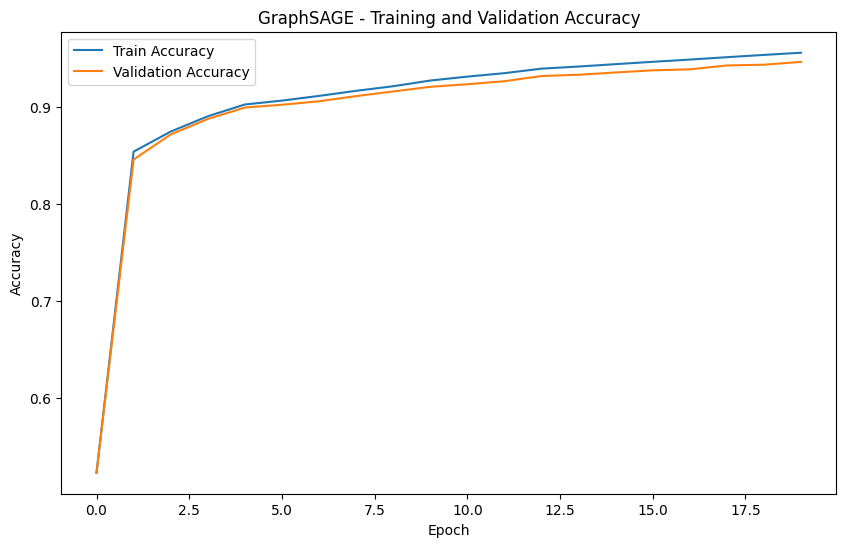

<Figure size 640x480 with 0 Axes>

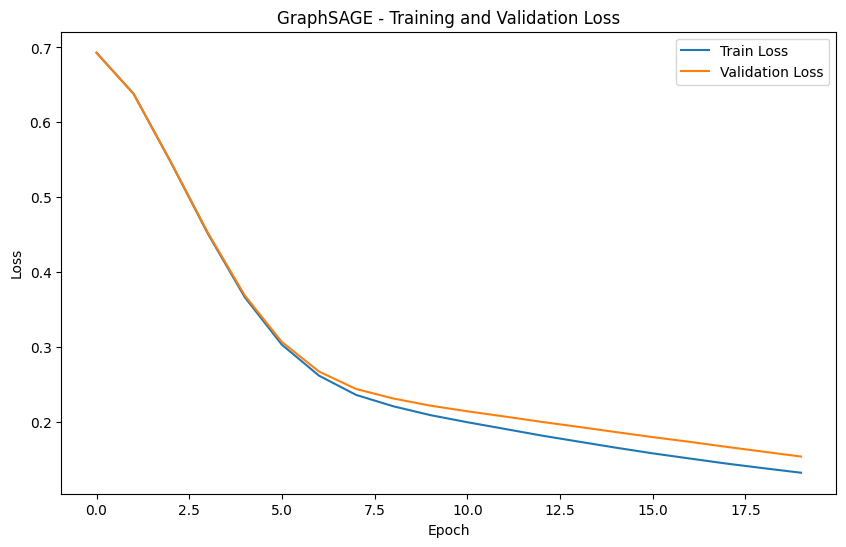

<Figure size 640x480 with 0 Axes>

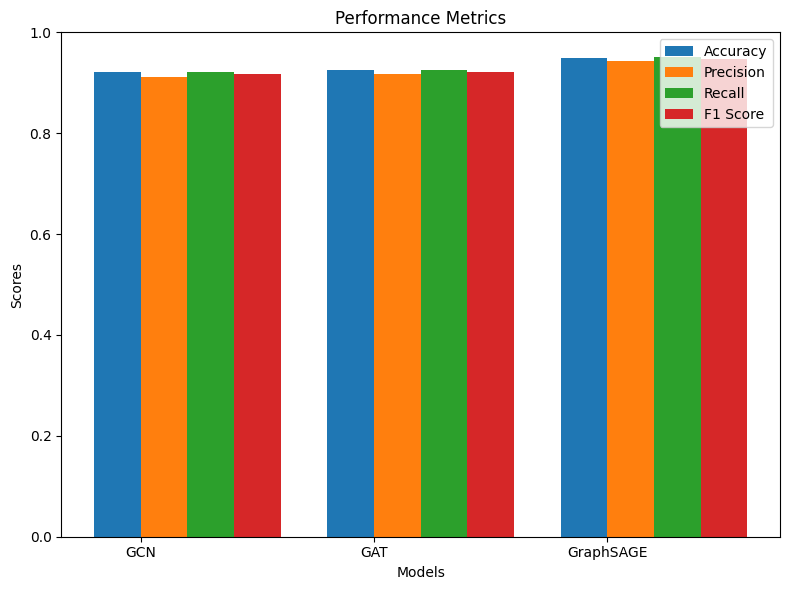

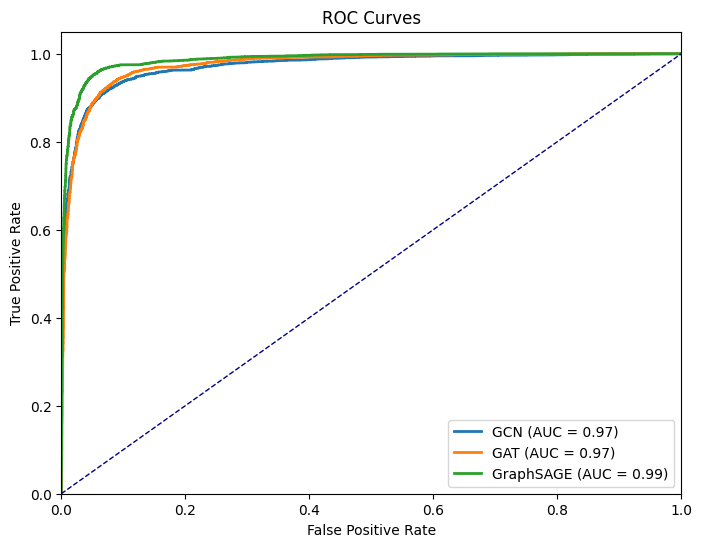

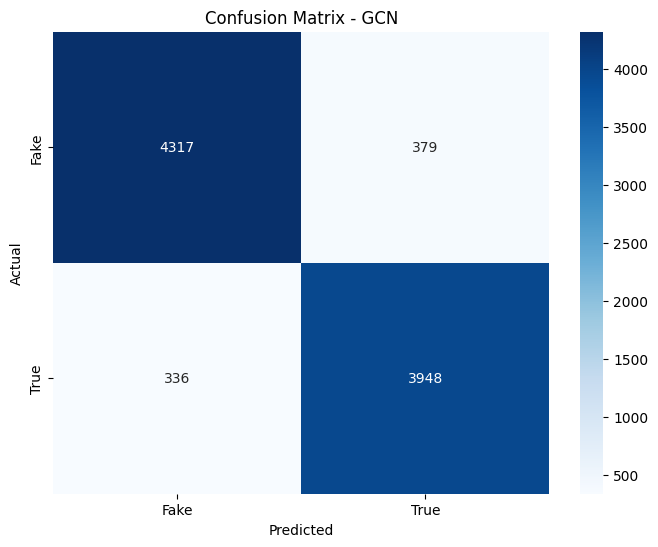

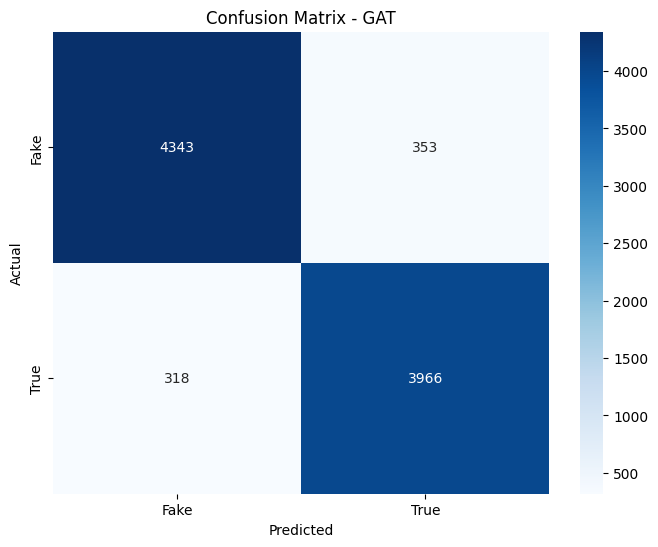

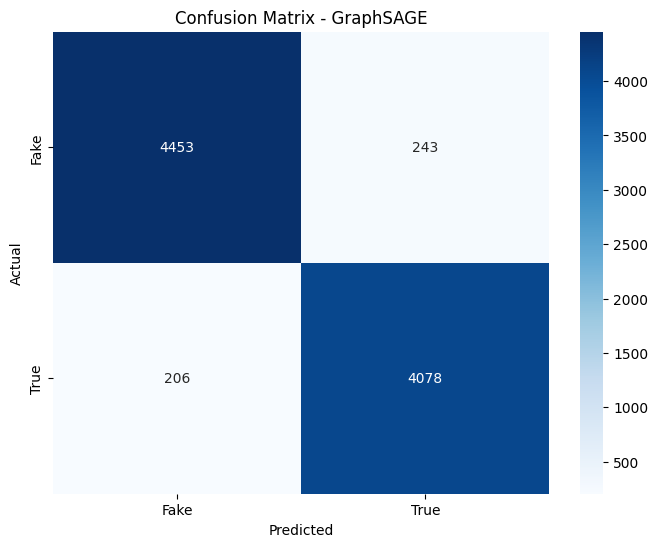

GNN models and preprocessing files saved successfully.


{'tokenizer': 'saved_models/gnn_tfidf_vectorizer.joblib',
 'graph_data': 'saved_models/gnn_graph_data.pt',
 'models': {'GCN': 'saved_models/gcn_model_state.pt',
  'GAT': 'saved_models/gat_model_state.pt',
  'GraphSAGE': 'saved_models/graphsage_model_state.pt'},
 'metrics': 'saved_models/gnn_model_metrics.json'}

In [6]:
# Save GNN models, TF-IDF tokenizer, graph data, and metrics

from pathlib import Path
import json
import joblib
import torch

SAVE_DIR = Path("saved_models")
MAX_FEATURES = 500
K_NEIGHBORS = 10
HIDDEN_DIM = 64
OUTPUT_DIM = 2

def save_models(results, tokenizer, data, histories=None, save_dir=SAVE_DIR):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    tokenizer_path = save_dir / "gnn_tfidf_vectorizer.joblib"
    graph_data_path = save_dir / "gnn_graph_data.pt"
    metrics_path = save_dir / "gnn_model_metrics.json"

    joblib.dump(tokenizer, tokenizer_path)

    torch.save({
        "x": data.x.detach().cpu(),
        "edge_index": data.edge_index.detach().cpu(),
        "y": data.y.detach().cpu(),
        "train_mask": data.train_mask.detach().cpu(),
        "test_mask": data.test_mask.detach().cpu(),
        "config": {
            "max_features": MAX_FEATURES,
            "k_neighbors": K_NEIGHBORS,
            "hidden_dim": HIDDEN_DIM,
            "output_dim": OUTPUT_DIM,
            "class_labels": {
                "0": "Fake",
                "1": "True"
            }
        }
    }, graph_data_path)

    model_configs = {
        "GCN": {
            "builder": "get_gcn",
            "input_dim": MAX_FEATURES,
            "hidden_dim": HIDDEN_DIM,
            "output_dim": OUTPUT_DIM
        },
        "GAT": {
            "builder": "get_gat",
            "input_dim": MAX_FEATURES,
            "hidden_dim": HIDDEN_DIM,
            "output_dim": OUTPUT_DIM
        },
        "GraphSAGE": {
            "builder": "get_graphsage",
            "input_dim": MAX_FEATURES,
            "hidden_dim": HIDDEN_DIM,
            "output_dim": OUTPUT_DIM
        }
    }

    saved_files = {
        "tokenizer": str(tokenizer_path),
        "graph_data": str(graph_data_path),
        "models": {}
    }

    metrics = {}

    for model_name, result in results.items():
        model = result["model"]
        model_path = save_dir / f"{model_name.lower()}_model_state.pt"

        torch.save({
            "model_name": model_name,
            "model_state_dict": {
                key: value.detach().cpu()
                for key, value in model.state_dict().items()
            },
            "model_config": model_configs[model_name],
            "history": histories.get(model_name) if histories else None
        }, model_path)

        saved_files["models"][model_name] = str(model_path)

        metrics[model_name] = {
            "accuracy": float(result["accuracy"]),
            "precision": float(result["precision"]),
            "recall": float(result["recall"]),
            "f1_score": float(result["f1_score"]),
            "roc_auc": float(result["roc_auc"]),
            "confusion_matrix": result["conf_matrix"].tolist(),
            "fpr": result["fpr"].tolist(),
            "tpr": result["tpr"].tolist()
        }

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=4)

    saved_files["metrics"] = str(metrics_path)

    print("GNN models and preprocessing files saved successfully.")
    return saved_files


# Main Execution
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    fake_path = "/kaggle/input/datasets/kankanachakraborty/fake-news/fake.csv"
    true_path = "/kaggle/input/datasets/kankanachakraborty/fake-news/true.csv"

    df = load_data(fake_path, true_path)
    X, y, tokenizer = prepare_data(df, max_features=MAX_FEATURES)
    data = create_graph_data(X, y, k=K_NEIGHBORS)

    models = {
        "GCN": get_gcn(input_dim=MAX_FEATURES, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM),
        "GAT": get_gat(input_dim=MAX_FEATURES, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM),
        "GraphSAGE": get_graphsage(input_dim=MAX_FEATURES, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM)
    }

    results = {}
    histories = {}

    for model_name, model in models.items():
        print(f"\n===== Training {model_name} =====")
        trained_model, history = train_and_evaluate(model, data)

        result = evaluate_model(trained_model, data, model_name)
        results[model_name] = result
        histories[model_name] = history

        plot_history(history, model_name)

    plot_comparison(results)
    plot_roc_curves(results)

    for model_name, result in results.items():
        plot_confusion_matrix(result["conf_matrix"], model_name)

    saved_gnn_files = save_models(results, tokenizer, data, histories)
    return results, histories, saved_gnn_files


results, histories, saved_gnn_files = main()
saved_gnn_files